In [10]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn

from conformal import get_conformal_module, get_percentile, clip_scores, calibrate_residual
from conformal_baselines import calc_baseline_mets
from data import get_dataloaders
from model import NN
from trainer import Trainer, get_optimizer, get_scheduler
from config import get_config_by_name
import utils as utils


In [11]:
config = get_config_by_name('tissuemnist')
config.conformal_module_name = 'random_aps'
config.num_epochs = 50
config.use_score_clipping = False 

utils.seed_everything(config.seed)
# utils.create_logger(config.exp_dir, config.dump_log)

logging.info('Config:')
for k, v in config.items():
    logging.info(f'{k}: {v}')
logging.info('')

conformal_module = get_conformal_module(config.conformal_module_name)
dls, t = get_dataloaders(config, conformal_module)
train_dl = dls['train']
valid_dl = dls['valid']
test_dl = dls['test']
baseline_mets = calc_baseline_mets(train_dl, valid_dl, alpha=config.alpha, k_raps=config.k_raps)


  2%|▏         | 2/100 [00:01<01:30,  1.08it/s]


In [12]:
config.hidden_dim = 128
config.input_dim = 8

model = NN(input_dim=config.input_dim,
            hidden_dim=config.hidden_dim,
            norm=config.norm,
            drop_rate=config.drop_rate,
            criteria_name=config.criteria_name)
model = model.to(config.device)
logging.info(model)

optimizer = get_optimizer(model, config)
scheduler = get_scheduler(optimizer, config)

criteria = nn.MSELoss()
trainer = Trainer(criteria=criteria,
                  metric_logger=utils.RegressionMetricLogger,
                  config=config,
                  input_key='probs')

trainer.fit(model=model,
            train_loader=train_dl,
            test_loader=valid_dl,
            optimizer=optimizer,
            scheduler=scheduler,
            valid_loader=valid_dl)

311it [00:01, 288.27it/s]
311it [00:01, 281.93it/s]
311it [00:01, 283.65it/s]
311it [00:01, 278.96it/s]
311it [00:01, 296.33it/s]
/home/royhirsch/miniconda3/envs/conf/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:152: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
311it [00:01, 278.57it/s]
311it [00:01, 285.75it/s]
311it [00:01, 296.32it/s]
311it [00:01, 300.09it/s]
311it [00:01, 283.30it/s]
311it [00:01, 280.38it/s]
311it [00:01, 279.87it/s]
311it [00:01, 300.21it/s]
311it [00:01, 283.59it/s]
311it [00:01, 289.56it/s]
311it [00:01, 275.55it/s]
311it [00

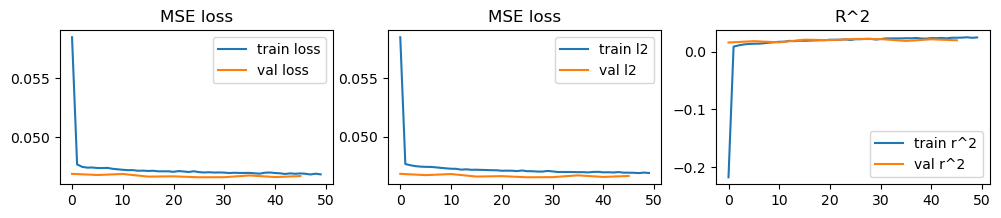

In [13]:
import matplotlib.pyplot as plt
import numpy as np

history = trainer.history
x_val = np.arange(0, len(history['loss']), config.val_interval)

plt.figure(figsize=(12,2))
plt.subplot(1,3,1)
plt.plot(history['loss'], label='train loss')
plt.plot(x_val, history['val_loss'], label='val loss')
plt.title('MSE loss')
plt.legend()

plt.subplot(1,3,2)
plt.plot(history['l2'], label='train l2')
plt.plot(x_val, history['val_l2'], label='val l2')
plt.title('MSE loss')
plt.legend()

plt.subplot(1,3,3)
plt.plot(history['r^2'], label='train r^2')
plt.plot(x_val, history['val_r^2'], label='val r^2')
plt.title('R^2')
plt.legend()

In [14]:
import numpy as np

alpha = 0.1
eps = 1e-6
max_value = 1.0 - eps

def quantize(preds, probs):
    quantize_scores = []
    for prob, pred in zip(probs, preds):
        cumsum = np.sort(prob)[::-1].cumsum()
        ind = np.argmin(np.abs(cumsum - pred))
        quantize_scores.append(cumsum[ind])
    return np.asarray(quantize_scores)

def calc_mets(probs, scores, labels):
    m = len(probs)
    val_pi = probs.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(probs, val_pi, axis=1).cumsum(axis=1)
    prediction_sets = np.take_along_axis(val_srt <= np.expand_dims(scores, 1), val_pi.argsort(axis=1), axis=1)

    print('mean size {:.3f} | acc {:.3f}'.format(prediction_sets.sum(1).mean(), 
                                                prediction_sets[np.arange(m), labels].mean()))
    return prediction_sets.sum(1).mean()


In [16]:
import numpy as np
from conformal import divide, calc_correction_bias

alpha = 0.1
eps = 1e-7

train_predict_out = trainer.predict(model, valid_dl)
test_predict_out = trainer.predict(model, test_dl)

calib_true_scores = train_predict_out['true_scores']
calib_pred_scores = train_predict_out['pred_scores']
calib_probs = train_predict_out['cls_probs']

valid_true_scores = test_predict_out['true_scores']
valid_true_labels = test_predict_out['cls_labels']
valid_pred_scores = test_predict_out['pred_scores']
valid_probs = test_predict_out['cls_probs']

# calib_pred_scores = np.minimum(calib_pred_scores, max_value - eps)
# valid_pred_scores = np.minimum(valid_pred_scores, max_value - eps)
# calib_pred_scores = quantize(calib_pred_scores, calib_probs)
# valid_pred_scores = quantize(valid_pred_scores, valid_probs)

diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_probs.max(1) + eps)
# diff = calib_true_scores - calib_pred_scores

# diff = diff[np.where(calib_pred_scores<global_qhat)[0]]
n = len(diff)
qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n)

modified_valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_probs.max(1) + eps)
# modified_valid_pred_scores = valid_pred_scores + qhat

n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
print('Residuals correction is {:.8f}, clip {:.2f}% of the samples'.format(
    qhat, n_over_one * 100.))

modified_valid_pred_scores = np.minimum(modified_valid_pred_scores, max_value - eps)
calc_mets(valid_probs, modified_valid_pred_scores, test_predict_out['cls_labels'])


Residuals correction is 1.38544307, clip 42.17% of the samples
mean size 3.317 | acc 0.578


3.317028027498678

# Random APS

In [6]:
import numpy as np

def get_quantized_scores_v4(pred_scores, probs):
    quantized_scores = []
    for s, p in zip(pred_scores, probs):
        sorted_p = np.sort(p)[::-1]
        cumsum = sorted_p.cumsum()
        for i in range(len(cumsum)):
            if cumsum[i] > s:
                break
        # print(i)
        if i == 0:
            quantized_scores.append(cumsum[i])
        else:
            quantized_scores.append((cumsum[i] + cumsum[i-1])/2.)
    return np.asarray(quantized_scores)

def get_quantized_scores_v3(pred_scores, probs):
    quantized_scores = []
    for s, p in zip(pred_scores, probs):
        sorted_p = np.sort(p)[::-1]
        cumsum = sorted_p.cumsum()
        for i in range(len(cumsum)):
            if cumsum[i] > s:
                break
        # print(i)
        if i == 0:
            quantized_scores.append(cumsum[i] * 0.5)
        else:
            quantized_scores.append((cumsum[i] + cumsum[i-1])/2.)
    return np.asarray(quantized_scores)

def get_quantized_scores_v2(pred_scores, probs):
    # take 0.5 into consideration
    quantized_scores = []
    for s, p in zip(pred_scores, probs):
        p = np.sort(p)[::-1]
        cumsum = []
        for i in range(len(p)):
            cumsum.append(sum(p[:i]) + 0.5 * p[i])
        cumsum = np.asarray(cumsum)
        # print(cumsum)
        ind = np.argmin(np.abs(cumsum - s))
        quantized_scores.append(cumsum[ind])
    return np.asarray(quantized_scores)

def get_random_sets_v4(valid_pred_scores, valid_probs):
    val_pi = valid_probs.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(valid_probs, val_pi, axis=1).cumsum(axis=1)

    n_val = val_srt.shape[0]
    cumsum_index = np.sum(val_srt <= np.expand_dims(valid_pred_scores, 1), axis=1)
    high = val_srt[np.arange(n_val), cumsum_index]
    low = np.zeros_like(high)
    low[cumsum_index > 0] = val_srt[np.arange(n_val), cumsum_index-1][cumsum_index > 0]
    prob = 0.5
    rv = np.random.binomial(1,prob,size=(n_val))
    randomized_threshold = low
    randomized_threshold[rv == 1] = high[rv == 1]
    randomized_threshold = np.maximum(randomized_threshold, val_srt[:, 0])
    prediction_sets = np.take_along_axis(val_srt <= randomized_threshold[:,None], val_pi.argsort(axis=1), axis=1)

    sets = []
    for p in prediction_sets:
        sets.append(tuple(np.where(p == True)[0].tolist()))
    return sets

def get_random_sets_v3(valid_pred_scores, valid_probs):
    val_pi = valid_probs.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(valid_probs, val_pi, axis=1).cumsum(axis=1)

    n_val = val_srt.shape[0]
    cumsum_index = np.sum(val_srt <= np.expand_dims(valid_pred_scores, 1), axis=1)
    high = val_srt[np.arange(n_val), cumsum_index]
    low = np.zeros_like(high)
    low[cumsum_index > 0] = val_srt[np.arange(n_val), cumsum_index-1][cumsum_index > 0]
    prob = (valid_pred_scores - low)/(high - low)
    rv = np.random.binomial(1,prob,size=(n_val))
    randomized_threshold = low
    randomized_threshold[rv == 1] = high[rv == 1]
    randomized_threshold = np.maximum(randomized_threshold, val_srt[:,0])
    prediction_sets = np.take_along_axis(val_srt <= randomized_threshold[:,None], val_pi.argsort(axis=1), axis=1)

    sets = []
    for p in prediction_sets:
        sets.append(tuple(np.where(p == True)[0].tolist()))
    return sets

def num_scores_bigger_then_one(scores):
    print(len(np.where(scores >= 0.99)[0]) / len(scores))

def get_random_sets_v2(scores, probs):
    sets = []
    for s, p, in zip(scores, probs):
        sorted_p = np.sort(p)[::-1]
        argsort_p = np.argsort(p)[::-1]
        cumsum_p = np.cumsum(sorted_p)            

        inds = np.where(cumsum_p < (s - 1e-8))[0]
        if len(inds):
            ind = inds[-1]
            prob = (cumsum_p[ind + 1] - s) / (cumsum_p[ind + 1] - cumsum_p[ind])
            if np.random.binomial(1, prob):
                ind += 1
        else:
            ind = len(p) - 1
        sets.append(tuple(argsort_p[:ind + 1]))
    return sets

def get_quantized_scores(pred_scores, probs):
    quantized_scores = []
    for s, p in zip(pred_scores, probs):
        cumsum = np.sort(p)[::-1].cumsum()
        ind = np.argmin(np.abs(cumsum - s))
        quantized_scores.append(cumsum[ind])
    return np.asarray(quantized_scores)

def get_random_scores(probs, labels):
    scores = []
    for p, l in zip(probs, labels):
            true_class_p = p[l]
            score = np.sum(p[p > true_class_p]) + 0.5 * true_class_p 
            scores.append(score)
    return np.asarray(scores)


In [9]:
import numpy as np
from conformal import divide, calc_correction_bias

alpha = 0.1
eps = 1e-7

train_predict_out = trainer.predict(model, valid_dl)
test_predict_out = trainer.predict(model, test_dl)
max_value = conformal_module.get_max_value(8)

# calib_true_scores  = get_random_scores(train_predict_out['cls_probs'], train_predict_out['cls_labels'])
calib_true_scores = train_predict_out['true_scores']

calib_pred_scores = train_predict_out['pred_scores']
calib_probs = train_predict_out['cls_probs']

# valid_true_scores  = get_random_scores(test_predict_out['cls_probs'], test_predict_out['cls_labels'])
valid_true_scores = test_predict_out['true_scores']

valid_pred_scores = test_predict_out['pred_scores']
valid_probs = test_predict_out['cls_probs']

calib_pred_scores = get_quantized_scores_v4(calib_pred_scores, calib_probs)
valid_pred_scores = get_quantized_scores_v4(valid_pred_scores, valid_probs)

# calib_pred_scores = np.zeros_like(calib_pred_scores)
# valid_pred_scores = np.zeros_like(valid_pred_scores)

# calib_pred_scores = calib_true_scores
# valid_pred_scores = valid_true_scores

num_scores_bigger_then_one(valid_pred_scores)

diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_probs.max(1) + eps)
# diff = calib_true_scores - calib_pred_scores

n = len(diff)
qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n)
print(f'qhat={qhat}')

valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_probs.max(1) + eps)
# valid_pred_scores = valid_pred_scores + qhat

num_scores_bigger_then_one(valid_pred_scores)
valid_pred_scores = np.clip(valid_pred_scores, a_min=valid_probs.max(1), a_max=max_value)
num_scores_bigger_then_one(valid_pred_scores)

conformal_module = get_conformal_module(config.conformal_module_name)
sets = conformal_module.get_sets(valid_pred_scores, valid_probs)
# sets = get_random_sets_v3(valid_pred_scores, valid_probs)

calibrated_test_mets = conformal_module.get_conformal_mets(
    sets, test_predict_out['cls_labels'])
print(calibrated_test_mets)



0.06292966684294024
qhat=0.4814184315939825
0.08434690639873083
0.08434690639873083
{'size_mean': 2.57297726070862, 'size_std': 0.7404170570083746, 'acc': 0.9246430460074034}


In [10]:
baseline_mets

{'naive': {'size_mean': 2.6604970914859862,
  'size_std': 1.314009275807639,
  'qhat': 0.9,
  'acc': 0.9457958751983078},
 'aps': {'size_mean': 3.4587519830777365,
  'size_std': 1.8160417808240552,
  'qhat': 0.9863331,
  'acc': 0.8947646747752512},
 'aps_randomized': {'size_mean': 2.3365943945002643,
  'size_std': 1.2242606782474037,
  'qhat': 0.901237708019801,
  'acc': 0.9164463246959281},
 'raps': {'size_mean': 2.658381808566896,
  'size_std': 1.3102360403391458,
  'qhat': 0.8998876264674694,
  'acc': 0.9457958751983078},
 'raps_randomized': {'size_mean': 2.294553146483342,
  'size_std': 1.2340861984985403,
  'qhat': 0.8992933345514224,
  'acc': 0.8987308302485457}}